In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

df = pd.read_csv('../data/processed/merged_dataset.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
print(df.shape)
df.head()

(250, 18)


,date,time_slot,room_id,occupancy,fan_status,light_status,ac_status,projector_status,power_consumption_w,day_of_week,is_break_period,is_after_hours,wastage_label,timestamp,hour_of_day,day_of_week_num,rolling_avg_30min,lag_1h_power
0,01-04-2026,8:30 AM,Lab2,1,1,1,0,0.0,460,Wednesday,0,0,0,2026-01-04 08:30:00,8,6,460.000000,0
1,01-04-2026,10:00 AM,Class1,1,1,1,0,0.0,460,Wednesday,1,0,0,2026-01-04 10:00:00,10,6,460.000000,460
2,01-04-2026,10:45 AM,StaffRoom,1,1,1,0,0.0,345,Wednesday,1,0,0,2026-01-04 10:45:00,10,6,421.666667,460
3,02-02-2026,9:00 AM,Lab2,0,0,0,0,0.0,0,Monday,0,0,0,2026-02-02 09:00:00,9,0,268.333333,345
4,02-02-2026,12:30 PM,Lab1,1,0,1,0,0.0,160,Monday,0,0,0,2026-02-02 12:30:00,12,0,168.333333,0


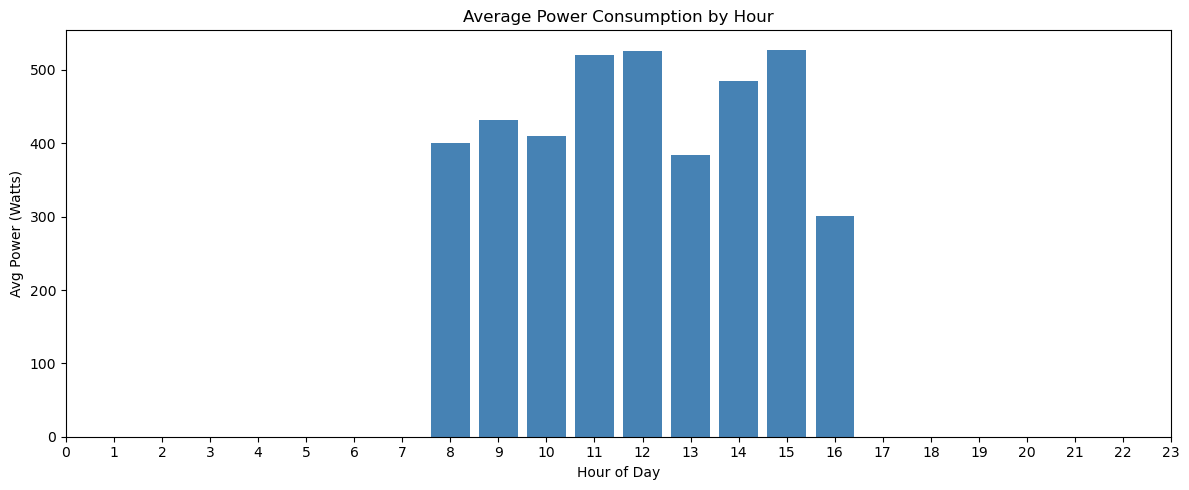

In [4]:
plt.figure(figsize=(12,5))
hourly = df.groupby('hour_of_day')['power_consumption_w'].mean()
plt.bar(hourly.index, hourly.values, color='steelblue')
plt.xlabel('Hour of Day')
plt.ylabel('Avg Power (Watts)')
plt.title('Average Power Consumption by Hour')
plt.xticks(range(0,24))
plt.tight_layout()
plt.savefig('../docs/power_by_hour.png')
plt.show()

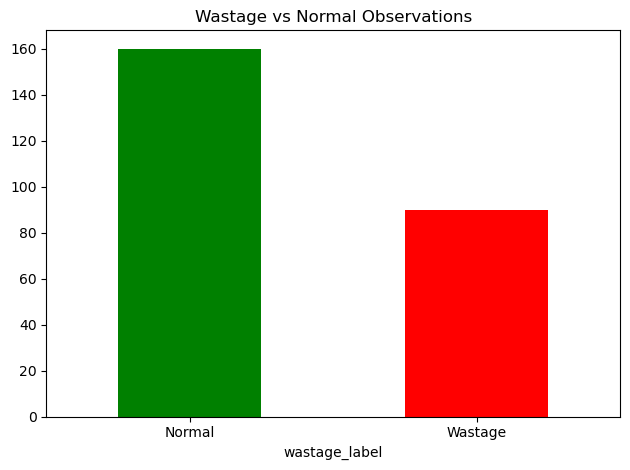

In [6]:
#Wastage label distribution:
df['wastage_label'].value_counts().plot(kind='bar', color=['green','red'])
plt.title('Wastage vs Normal Observations')
plt.xticks([0,1], ['Normal','Wastage'], rotation=0)
plt.tight_layout()
plt.show()

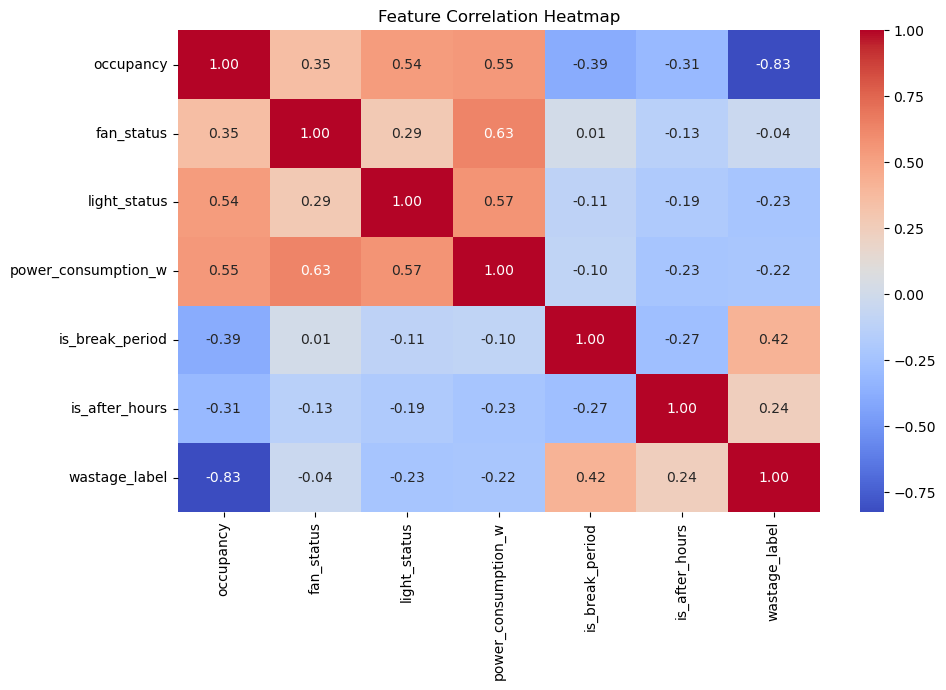

In [7]:
#Correlation heatmap:
plt.figure(figsize=(10,7))
cols = ['occupancy','fan_status','light_status','power_consumption_w',
        'is_break_period','is_after_hours','wastage_label']
sns.heatmap(df[cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('../docs/correlation_heatmap.png')
plt.show()